In [2]:
# ================== 读取 → 标记HVG(不截断) → 在HVG上做PCA → 邻接 → UMAP → Leiden（保存结果且保留全基因） ==================
import scanpy as sc
import pandas as pd
from pathlib import Path
import numpy as np

# ----------------- 路径与参数 -----------------
in_path   = r"data/region_gene_full_raw.xlsx"      # 首列=region；最后两列依次=y,x；中间=表达
out_dir   = Path("data/umap_better"); out_dir.mkdir(parents=True, exist_ok=True)

# 初次（全量）分群参数（保持你的取值）
n_top_seed   = 130
n_neighbors1 = 20
n_pcs1       = 40
res_seed     = 1.2

# ----------------- 读取：首列=region，末两列=y,x，中间=表达 -----------------
df0 = pd.read_excel(in_path, header=0)
df  = df0.set_index(df0.columns[0])              # region 索引
y = df.iloc[:, -2].astype(float).values
x = df.iloc[:, -1].astype(float).values
X_num = df.iloc[:, :-2].astype(float)            # 表达矩阵（region x gene）

# ----------------- AnnData（保留全基因） -----------------
adata = sc.AnnData(X_num.values)
adata.obs_names = [str(i) for i in X_num.index]   # region
adata.var_names = [str(c) for c in X_num.columns] # gene
adata.obs["y"] = y
adata.obs["x"] = x

# 可选：把“当前的全基因原始表达”存入 raw 作为快照（方便后续 rank_genes_groups / dotplot）
adata.raw = adata.copy()

print("Raw shape (regions x genes):", adata.n_obs, "x", adata.n_vars)

# ----------------- HVG(不subset) → 在HVG上做scale/PCA -----------------
# 只打标，不截断基因（subset=False）
sc.pp.highly_variable_genes(
    adata, flavor='seurat_v3',
    n_top_genes=min(n_top_seed, adata.n_vars),
    subset=False
)
hvgs = adata.var["highly_variable"].to_numpy()

# 在 HVG 子集上做 scale / PCA（不改变 adata 的基因维度）
tmp = adata[:, hvgs].copy()
sc.pp.scale(tmp, zero_center=True,max_value=10)
sc.tl.pca(tmp, n_comps=min(50, tmp.n_vars), random_state=42)

# 把 PCA 结果写回到“全基因”的 adata
adata.obsm["X_pca"]   = tmp.obsm["X_pca"]                 # (n_obs, n_pcs)
adata.uns["pca"]      = tmp.uns.get("pca", {})            # 载荷方差等
adata.varm["PCs"]     = np.zeros((adata.n_vars, adata.obsm["X_pca"].shape[1]))
adata.varm["PCs"][hvgs, :] = tmp.varm["PCs"]              # 仅 HVG 有真实载荷，其余置 0

# ----------------- 邻接 → UMAP → Leiden -----------------
sc.pp.neighbors(
    adata,
    n_neighbors=n_neighbors1,
    n_pcs=min(n_pcs1, adata.obsm["X_pca"].shape[1]),
    metric='cosine'
)
sc.tl.umap(adata, min_dist=0.1, random_state=42)

seed_key = f"leiden_seed_{res_seed}"
sc.tl.leiden(adata, resolution=res_seed, key_added=seed_key, random_state=42)
adata.obs["seed"] = adata.obs[seed_key].astype("category")
print("Seed clusters:", adata.obs["seed"].value_counts().sort_index().to_dict())

# ----------------- 保存结果（无绘图） -----------------
# 1) 保存含 UMAP/PC/聚类标签、且“保留全基因表达”的 h5ad
adata.write(out_dir / "adata_seed_pipeline_fullgenes.h5ad")

# 2) 保存一个 region→cluster 的 CSV 映射（含坐标）
assign_csv = out_dir / "region_seed_assignment.csv"
adata.obs[["seed", "x", "y"]].to_csv(assign_csv, index=True)  # index=region

print("Saved:", out_dir / "adata_seed_pipeline_fullgenes.h5ad")
print("Saved:", assign_csv)


Raw shape (regions x genes): 212 x 731


c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed clusters: {'0': 40, '1': 30, '2': 28, '3': 23, '4': 23, '5': 21, '6': 18, '7': 11, '8': 9, '9': 9}
Saved: data\umap_better\adata_seed_pipeline_fullgenes.h5ad
Saved: data\umap_better\region_seed_assignment.csv


C:\Users\Administrator\AppData\Local\Temp\ipykernel_23096\2986405533.py:66: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=res_seed, key_added=seed_key, random_state=42)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_23096\4002266811.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(K, 20))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23096\4002266811.py:35: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x, y, s=4, c=(0.8, 0.8, 0.8), alpha=0.35)


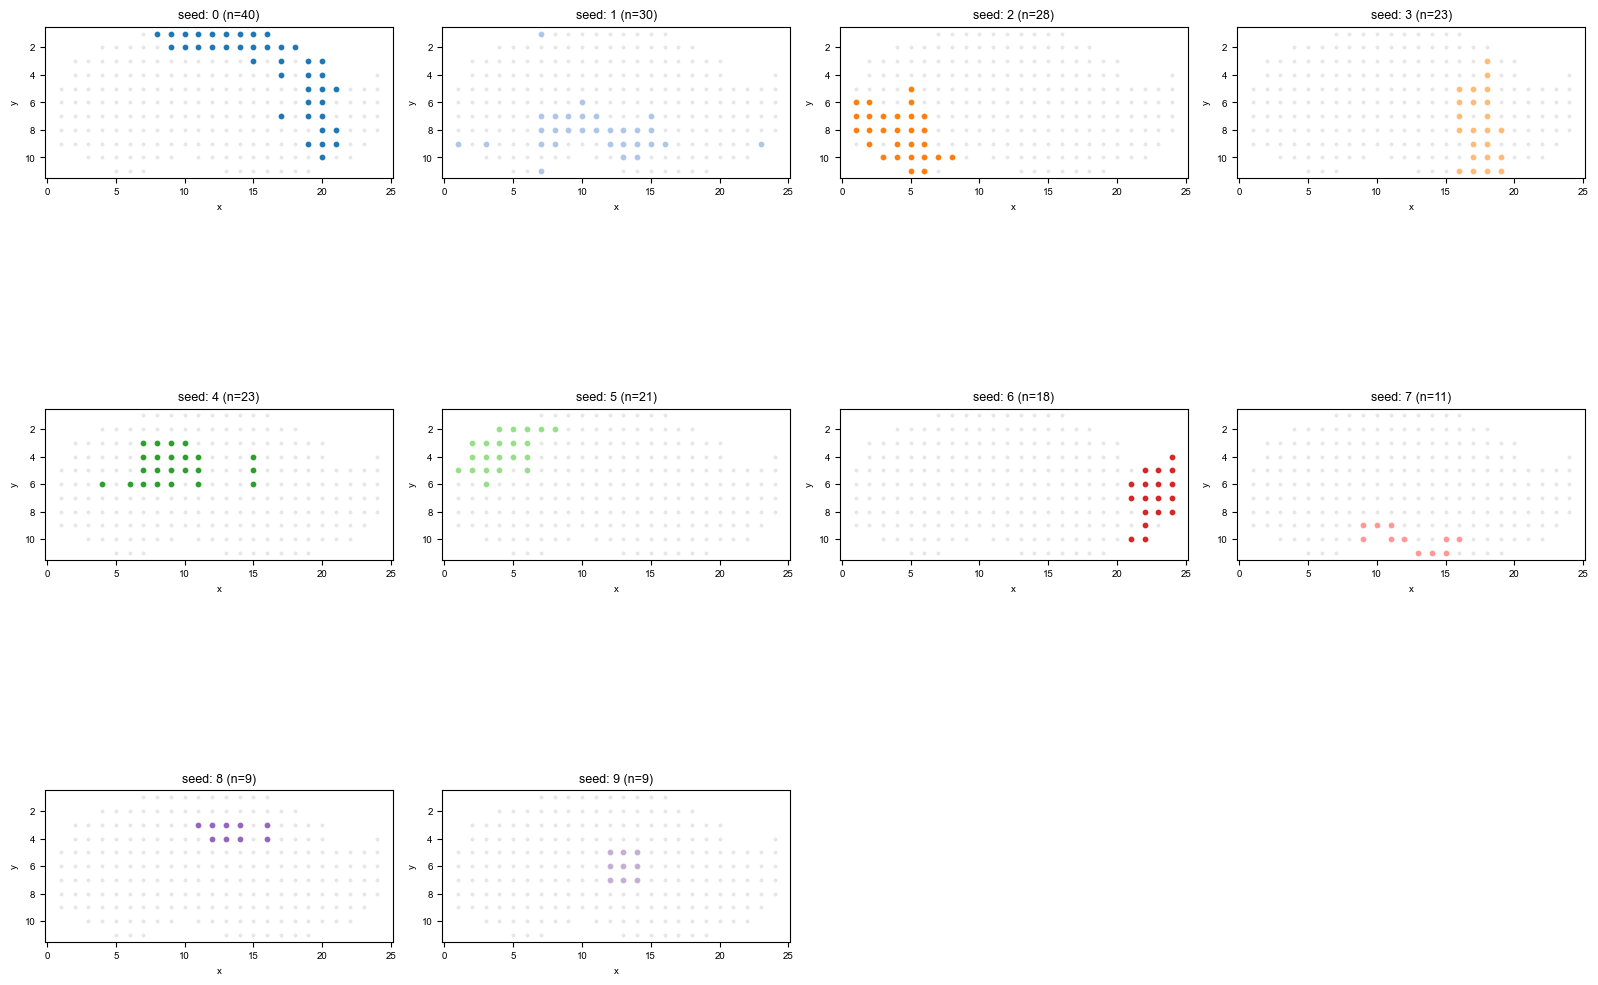

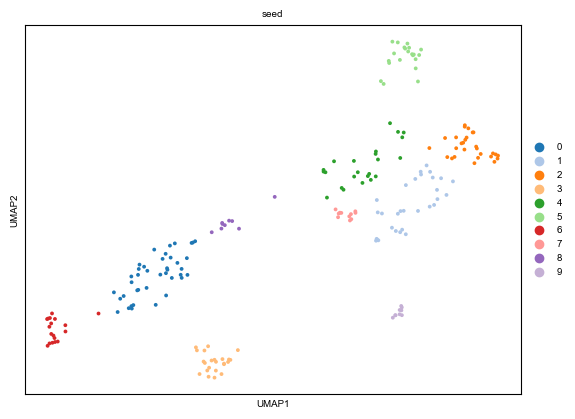

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from math import ceil
cluster_key  = "seed"
invert_y = True
# ================== 5. 统一颜色 ==================
cats   = pd.Categorical(adata.obs[cluster_key])
labels = list(cats.categories.astype(str))
K      = len(labels)

# 生成一套颜色（tab20 循环）
cmap = cm.get_cmap("tab20", max(K, 20))
pal  = [mcolors.to_hex(cmap(i % cmap.N)) for i in range(K)]

# 让 scanpy 也用这套颜色
adata.uns[f"{cluster_key}_colors"] = pal

# ================== 6. 画“每个簇一张”的空间图 ==================
x = adata.obs["x"].to_numpy(float)
y = adata.obs["y"].to_numpy(float)

ncols = min(4, K)
nrows = ceil(K / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for i, lab in enumerate(labels):
    ax  = axes[i]
    sel = (cats == lab)
    # 背景灰
    ax.scatter(x, y, s=4, c=(0.8, 0.8, 0.8), alpha=0.35)
    # 当前簇高亮
    ax.scatter(x[sel], y[sel], s=10, c=pal[i])
    ax.set_title(f"{cluster_key}: {lab} (n={int(sel.sum())})", fontsize=9)
    ax.set_aspect("equal", adjustable="box")
    if invert_y:
        ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")

# 去掉多余子图
for j in range(K, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ================== 7. 画 UMAP（颜色跟上面一致） ==================
fig2 = sc.pl.umap(
    adata,
    color=cluster_key,
    size=30,
    show=False,
    return_fig=True,
)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23096\205019330.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(K, 20))  # 使用 tab20 调色板
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23096\205019330.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # 不改变 axes 宽高，仅整理整体空白


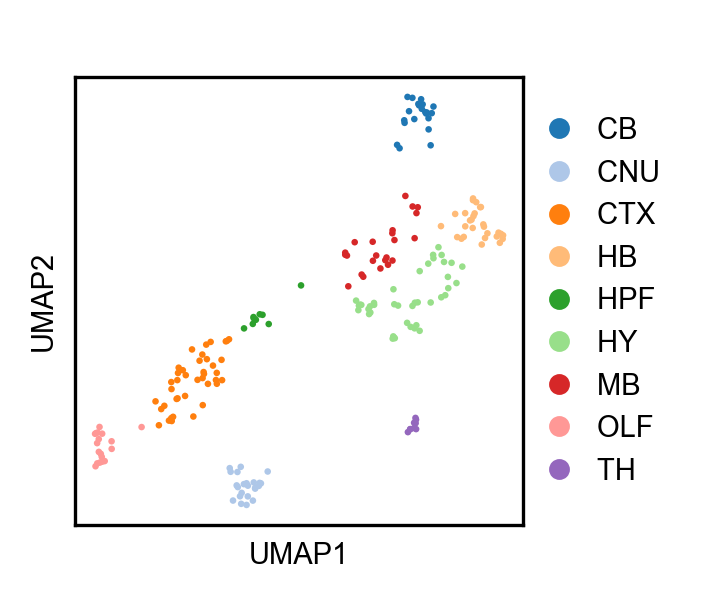

Saved: data\umap_better\umap_cluster_axes_3p8cm_Arial_same_svg_pdf.png
Saved: data\umap_better\umap_cluster_axes_3p8cm_Arial_same_svg_pdf.svg
Saved: data\umap_better\umap_cluster_axes_3p8cm_Arial_same_svg_pdf.pdf


In [5]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import Divider, Size
from pathlib import Path

# --------- 路径（若你已有 out_dir 变量，可注释掉这两行）---------
out_dir = Path("data/umap_better")
out_dir.mkdir(parents=True, exist_ok=True)

# --------- 字体/导出设置：Arial；让 SVG/PDF 看起来一致 ---------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,     # PDF 嵌入 TrueType 字体（文字可编辑）
    "svg.fonttype": "path", # SVG 将文字转为路径，避免系统字体差异
})

# --------- 1) 重命名分群：seed -> cluster ----------
rename_map = {
    '0': 'CTX',
    '1': 'HY',
    '2': 'HB',
    '3': 'CNU',
    '4': 'MB',
    '5': 'CB',
    '6': 'OLF',
    '7': 'HY',   # 根据你的需要将群体合并
    '8': 'HPF',
    '9': 'TH',
}

# 假设已经完成了分群，下面是重命名部分
old = adata.obs["seed"].astype(str)  # 确保 'seed' 是字符串类型
new = old.map(rename_map).fillna(old)  # 填充那些无法匹配的群体
adata.obs["cluster"] = pd.Categorical(new)  # 赋值为新的分群列

# --------- 2) 固定 axes 为 3.8cm×3.8cm，字号 7pt，并绘制 UMAP ----------
cm2inch = 1 / 2.54  # 转换因子：厘米到英寸
ax_w_in = 3.8 * cm2inch
ax_h_in = 3.8 * cm2inch

# 预留边距（英寸）
left_in, right_in, bottom_in, top_in = 0.2, 1.0, 0.2, 0.2
fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

fig = plt.figure(figsize=(fig_w, fig_h), dpi=300)
ax = plt.axes([0, 0, 1, 1])  # 占位

# 用 Divider 精确定位并固定 axes 尺寸
h = [Size.Fixed(left_in),  Size.Fixed(ax_w_in),  Size.Fixed(right_in)]
v = [Size.Fixed(bottom_in), Size.Fixed(ax_h_in), Size.Fixed(top_in)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
ax.set_axes_locator(divider.new_locator(nx=1, ny=1))

# --------- 3) 生成颜色映射，确保图例和散点一致 ---------
cats = pd.Categorical(adata.obs["cluster"])
labels = list(cats.categories.astype(str))
K = len(labels)
cmap = cm.get_cmap("tab20", max(K, 20))  # 使用 tab20 调色板
pal = [mcolors.to_hex(cmap(i % cmap.N)) for i in range(K)]

# 将颜色映射赋给 adata.uns['cluster_colors']
adata.uns["cluster_colors"] = pal

# --------- 4) UMAP 主图（按 cluster 上色） ---------
sc.pl.umap(
    adata,
    color="cluster",
    size=10,                 # 点大小可按需调整
    legend_loc=None,         # 图例我们自己在右侧生成（或保留 None 不显示）
    ax=ax,
    show=False
)

# —— 关键：让散点在两个后端都光栅化，减少 SVG/PDF 渲染差异 —— 
# for coll in ax.collections:
#     try:
#         coll.set_rasterized(True)
#         coll.set_linewidth(0.0)
#     except Exception:
#         pass

# 统一字号 7pt
ax.tick_params(labelsize=7)
ax.set_xlabel("UMAP1", fontsize=7)
ax.set_ylabel("UMAP2", fontsize=7)
ax.set_title(" ", fontsize=7)

# 自定义图例（右侧）
handles = []
for i, lab in enumerate(labels):
    handles.append(plt.Line2D([0], [0], marker='o', linestyle='',
                              markersize=4, color=pal[i], label=f"{lab} "))
leg = ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
                fontsize=7, frameon=False, handlelength=1.0, borderaxespad=0.0)

plt.tight_layout()  # 不改变 axes 宽高，仅整理整体空白

# --------- 5) 保存：PNG / SVG / PDF（SVG/PDF 外观一致） ----------
stem = out_dir / "umap_cluster_axes_3p8cm_Arial_same_svg_pdf"
fig.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")
fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

print("Saved:", stem.with_suffix(".png"))
print("Saved:", stem.with_suffix(".svg"))
print("Saved:", stem.with_suffix(".pdf"))


C:\Users\Administrator\AppData\Local\Temp\ipykernel_36288\2095738583.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(K, 20))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_36288\2095738583.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x, y, s=4, c=(0.85,0.85,0.85), alpha=0.25, linewidths=0)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_36288\2095738583.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorr

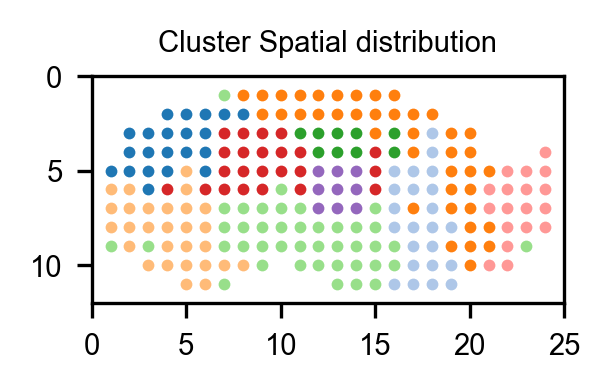

Saved: data\umap_better\spatial_cluster_axes_4x3p5cm_Arial.png
Saved: data\umap_better\spatial_cluster_axes_4x3p5cm_Arial.svg
Saved: data\umap_better\spatial_cluster_axes_4x3p5cm_Arial.pdf


In [4]:
# ===== 空间分布（axes=4cm×3.5cm，Arial 7pt，有边框、无轴标题，刻度从1步长5；保存 PNG/SVG/PDF）=====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import Divider, Size
from pathlib import Path

# --------- 输出目录（若已有 out_dir 变量可复用）---------
out_dir = Path("data/umap_better")
out_dir.mkdir(parents=True, exist_ok=True)

# --------- 字体：Arial，且确保导出为可编辑文本 ---------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,                 # 全局 7pt
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,             # 嵌入 TrueType（文字可编辑）
    "svg.fonttype": "none",         # SVG 保留文字，不转路径
})

cluster_key = "cluster"   # 如需用 seed 就改 "seed"
invert_y    = True

# --------- 数据 ---------
x = np.asarray(adata.obs["x"], dtype=float)
y = np.asarray(adata.obs["y"], dtype=float)
cats = pd.Categorical(adata.obs[cluster_key])
labels = list(cats.categories.astype(str))
K = len(labels)
cmap = cm.get_cmap("tab20", max(K, 20))
pal  =adata.uns["cluster_colors"]

# --------- 固定 axes 尺寸：4cm × 3.5cm（figure 只留极小边距）---------
cm2inch = 1/2.54
ax_w_in = 4.0 * cm2inch
ax_h_in = 3.5 * cm2inch
left_in, right_in, bottom_in, top_in = 0.5, 0.5, 0.5, 0.5
fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

fig = plt.figure(figsize=(fig_w, fig_h), dpi=300)
ax  = plt.axes([0, 0, 1, 1])  # 占位
h = [Size.Fixed(left_in),  Size.Fixed(ax_w_in),  Size.Fixed(right_in)]
v = [Size.Fixed(bottom_in), Size.Fixed(ax_h_in), Size.Fixed(top_in)]
ax.set_axes_locator(Divider(fig, (0,0,1,1), h, v, aspect=False).new_locator(nx=1, ny=1))

# --------- 绘制：灰底 + 各类高亮 ---------
ax.scatter(x, y, s=4, c=(0.85,0.85,0.85), alpha=0.25, linewidths=0)
for i, lab in enumerate(labels):
    sel = (cats == lab)
    ax.scatter(x[sel], y[sel], s=8, c=pal[i], linewidths=0)

# 坐标方向/比例
if invert_y:
    ax.invert_yaxis()
ax.set_aspect("equal", adjustable="box")

# 外观：保留边框；无坐标轴标题
ax.set_xlabel("")
ax.set_ylabel("")
for side in ["left","right","top","bottom"]:
    ax.spines[side].set_visible(True)

# 刻度：从1开始，步长=5，覆盖到最大值
xmax   = np.nanmax(x); ymax = np.nanmax(y)
x_last = 1 + 5*np.ceil((xmax - 1)/5) if xmax >= 1 else 1
y_last = 1 + 5*np.ceil((ymax - 1)/5) if ymax >= 1 else 1
ax.set_xlim(1, x_last-1)
if invert_y:
    ax.set_ylim(y_last+1, 1)
else:
    ax.set_ylim(1, y_last)
ax.set_xticks(np.arange(0, 25 + 1e-9, 5))
ax.set_yticks(np.arange(0, 13 + 1e-9, 5))
ax.tick_params(labelsize=7)
ax.set_title("Cluster Spatial distribution", fontsize=7)
plt.tight_layout()  # 不改变固定的 axes 尺寸

# --------- 保存为 PNG / SVG / PDF ---------
stem = out_dir / "spatial_cluster_axes_4x3p5cm_Arial"
fig.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")
fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")

plt.show()
print("Saved:", stem.with_suffix(".png"))
print("Saved:", stem.with_suffix(".svg"))
print("Saved:", stem.with_suffix(".pdf"))


In [5]:
bdata = adata.copy()

Removed from adata: ['Ubc', 'Fth1', 'Actb']
Removed from adata.raw: ['Ubc', 'Fth1', 'Actb']
Saved markers CSV: data\umap_better\markers_top10_by_cluster.csv


c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_

Saved: data\umap_better\dotplot_markers_top10_by_cluster_14x3p7cm_Reds.png


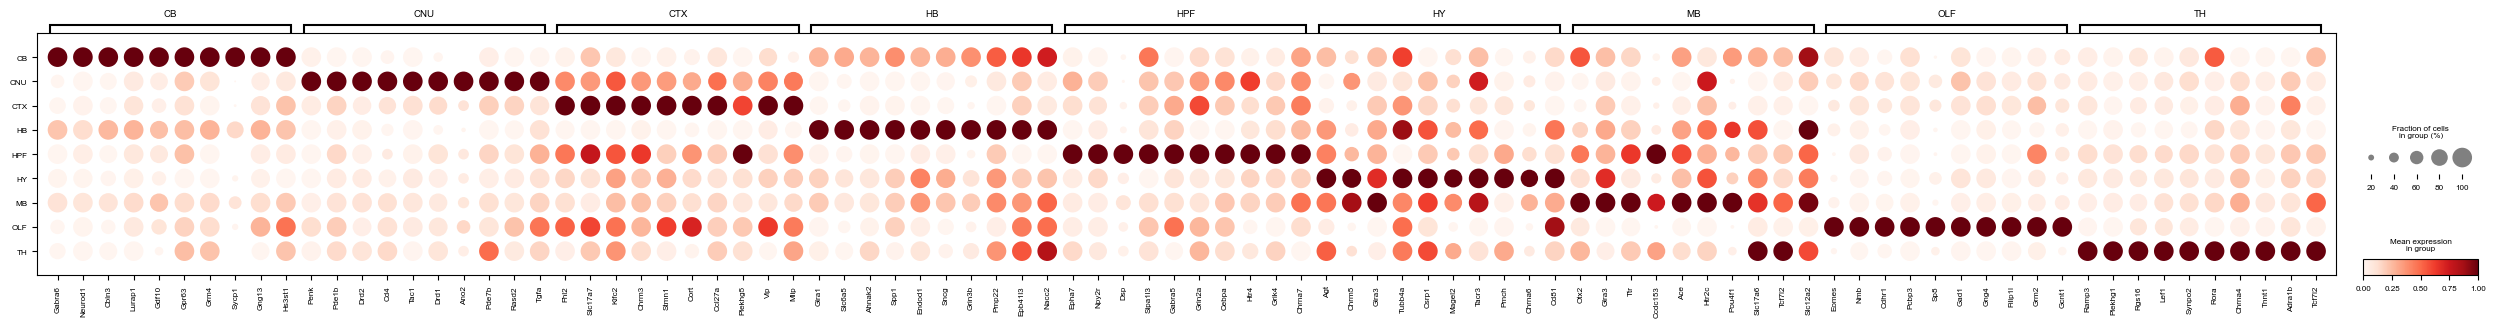

In [6]:
adata = bdata.copy()
# ==== 列出要删除的基因（需与 adata.var_names 完全一致，区分大小写）====
genes_to_drop = ["Actb", "Fth1", "Ubc"]  # ← 按需修改

# ---- 规范为字符串并去重 ----
genes_to_drop = list({str(g) for g in genes_to_drop})

# ---- 计算存在/缺失清单（仅提示）----
present = [g for g in genes_to_drop if g in adata.var_names]
missing = [g for g in genes_to_drop if g not in adata.var_names]
if missing:
    print("Not found (skip):", missing)
if not present:
    print("No genes removed.");  # 没有可删的就到此为止
else:
    # ---- 在主矩阵中删除这些基因 ----
    adata._inplace_subset_var(~adata.var_names.isin(present))
    print(f"Removed from adata: {present}")

    # ---- 若 adata.raw 存在，也同步删除 ----
    if adata.raw is not None:
        raw = adata.raw.to_adata()
        raw._inplace_subset_var(~raw.var_names.isin(present))
        adata.raw = raw
        print(f"Removed from adata.raw: {present}")

# ================== 计算每簇 Marker 并绘制 Dotplot（5基因/簇，14cm×3.7cm，白→红，Arial 7pt） ==================
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -------- 参数 --------
groupby        = "cluster"   # 你的分群列（若用 'seed' 就改这里）
top_n_per_grp  = 10           # 每簇挑多少个 marker（你要 5）
min_logfc      = 0.25        # 最小 log2FC（可调）
min_in_frac    = 0.10        # 簇内表达比例下限（可调）
max_out_frac   = 0.20        # 簇外表达比例上限（略放宽，避免过严拿不到5个）
method         = "wilcoxon"
use_raw        = False

out_dir = Path("data/umap_better"); out_dir.mkdir(parents=True, exist_ok=True)

# 字体/导出（Arial；PDF嵌TrueType；SVG保留文本）
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

sc.pp.scale(adata, zero_center=True)
# -------- 1) 计算差异基因（若已计算过可跳过本段）--------
sc.tl.rank_genes_groups(
    adata,
    groupby=groupby,
    method=method,
    use_raw=use_raw,
    pts=True,                 # 生成 pts / pts_rest（表达比例）
    key_added="markers"
)

rg = adata.uns["markers"]
groups = rg["names"].dtype.names  # 各簇名（顺序即显示顺序）

def _vec(rg, key, g):
    """从 rank_genes_groups 结果中取出某组 g 的向量（np.array）。"""
    arr = rg.get(key, None)
    if arr is None: return None
    return np.array(arr[g])

def top_markers_for_group(g):
    names = pd.Series(_vec(rg, "names", g), name="gene").astype(str)
    pvals = _vec(rg, "pvals_adj", g)
    if pvals is None: pvals = _vec(rg, "pvals", g)
    pval  = pd.Series(pvals, name="pval")
    lfc   = pd.Series(_vec(rg, "logfoldchanges", g), name="log2fc")
    score = pd.Series(_vec(rg, "scores", g), name="score")
    pts   = _vec(rg, "pts", g)
    ptsr  = _vec(rg, "pts_rest", g)
    frac_in  = pd.Series(pts  if pts  is not None else np.full(len(names), np.nan), name="frac_in")
    frac_out = pd.Series(ptsr if ptsr is not None else np.full(len(names), np.nan), name="frac_out")

    df = pd.concat([names, lfc, pval, score, frac_in, frac_out], axis=1)

    # 过滤：差异强 & 特异（不过严，确保能取到5个）
    keep = (df["log2fc"] >= min_logfc) & (df["frac_in"] >= min_in_frac)
    keep &= (df["frac_out"].fillna(0) <= max_out_frac)
    dff = df[keep].copy()
    if dff.empty: dff = df.copy()  # 兜底

    # 排序：log2FC优先，其次score
    dff = dff.sort_values(["log2fc", "score"], ascending=[False, False])
    return dff.head(top_n_per_grp).assign(group=g)

# -------- 2) 汇总每簇前N个 marker，必要时补齐到5 --------
parts = [top_markers_for_group(g) for g in groups]
markers_df = pd.concat(parts, axis=0, ignore_index=True)

# 若某簇不足 N 个，用原始候选顺序补齐
need_counts = markers_df.groupby("group")["gene"].count().reindex(groups).fillna(0).astype(int)
for g in groups:
    need = top_n_per_grp - need_counts[g]
    if need > 0:
        base_names = pd.Series(_vec(rg, "names", g)).astype(str).tolist()
        have = set(markers_df.loc[markers_df["group"]==g, "gene"])
        add = [nm for nm in base_names if nm not in have][:need]
        if add:
            add_df = pd.DataFrame({"gene": add, "group": g})
            markers_df = pd.concat([markers_df, add_df], axis=0, ignore_index=True)

# 导出 CSV（可选）
csv_path = out_dir / f"markers_top{top_n_per_grp}_by_{groupby}.csv"
markers_df.to_csv(csv_path, index=False)
print("Saved markers CSV:", csv_path)

# -------- 3) Dotplot：白→红；整体 14cm×3.7cm；Arial 7pt --------
# 组织成 {簇: [基因列表]}，按 groups 顺序
markers_dict = {g: markers_df.loc[markers_df["group"]==g, "gene"].tolist() for g in groups}

# 转厘米为英寸
w_in = 80 / 2.54
h_in = 8 / 2.54

# 返回 DotPlot 对象；设置颜色白→红（Reds），按基因标准化
dp = sc.pl.dotplot(
    adata,
    var_names=markers_dict,
    groupby=groupby,
    standard_scale="var",   # 每个基因按自身范围上色（有利于跨簇比较）
    dot_max=0.6,
    smallest_dot=0.1,
    cmap="Reds",
    dendrogram=False,
    figsize=(w_in, h_in),   # 整体图宽×高（英寸）
    return_fig=True
)

# 去掉点的边框（更干净）
dp = dp.style(dot_edge_lw=0.0)
dp = dp.style(cmap='Reds', dot_edge_lw=0.0)
# 保存为 PNG / SVG / PDF
stem = out_dir / f"dotplot_markers_top{top_n_per_grp}_by_{groupby}_14x3p7cm_Reds"
dp.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
print("Saved:", stem.with_suffix(".png"))



In [6]:
# ================== 自定义 Dotplot + 颜色/大小图例（Reds；Arial 7pt；14×3.8 cm） ==================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.collections import PathCollection
from pathlib import Path

# -------- 参数 --------
groupby = "cluster"     # 分组列（类别型）
# genes = [
#     "Gabra6","Neurod1","Cbln3",        # CB
#     "Drd1","Gpr6","Drd2",              # CNU
#     "Slc17a7","Tnnc1","Fhl2",          # CTX
#     "Slc6a5","Glra1","Sncg",           # HB
#     "Dsp","Ccdc153","Crlf1",           # HPF
#     "Agt","Pmch","Magel2",             # HY
#     "Htr2c","Pou4f1","Otx2",           # MB
#     "Gng4","Sp8","Cdhr1",              # OLF
#     "Plekhg1","Ramp3","Lef1",          # TH
# ]
genes = [
    "Gabra6","Neurod1",       # CB
    "Drd1","Drd2",              # CNU
    "Slc17a7","Fhl2",          # CTX
    "Slc6a5","Glra1",           # HB
    "Dsp","Ccdc153",           # HPF
    "Pmch","Magel2",             # HY
    "Pou4f1","Ace",           # MB
    "Gng4","Sp8",              # OLF
    "Ramp3","Lef1",          # TH
]
# 点径（毫米）——精确“物理大小”
MAX_DIAM_MM = 1.8     # 最大直径（表达比例=1）
MIN_DIAM_MM = 0.30    # 最小直径（表达比例很低的下限）

# “表达阈值”：>0 视为表达（可改为 >1 等）
EXP_THRESH = 0.0

# 输出目录
out_dir = Path("data/umap_better"); out_dir.mkdir(parents=True, exist_ok=True)
stem = out_dir / "dotplot_custom_genes_cluster_14x3p8_Reds_phys_with_legend"

# 字体/全局样式
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,   # PDF 嵌 TrueType
    "svg.fonttype": "none"
})

# -------- 准备数据：分组顺序、基因存在性 --------
if groupby not in adata.obs:
    raise ValueError(f"adata.obs 中找不到列：{groupby}")

cats = pd.Categorical(adata.obs[groupby])
groups = list(cats.categories.astype(str))

# 基因去重并保持顺序；过滤不存在的基因
varset = set(map(str, adata.var_names))
genes_clean, seen = [], set()
for g in genes:
    if g in varset and g not in seen:
        genes_clean.append(g); seen.add(g)
miss = [g for g in genes if g not in varset]
if not genes_clean:
    raise ValueError("给定基因均不在 adata.var_names 中。")
if miss:
    print("未找到的基因（忽略）：", miss)

# 取表达矩阵（优先 raw）
if getattr(adata, "raw", None) is not None:
    X = adata.raw[:, genes_clean].X
else:
    X = adata[:, genes_clean].X

# 稀疏转致密
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.asarray(X, dtype=float)  # n_obs x n_genes

# -------- 计算每（group, gene）的“表达均值”和“表达比例” --------
obs_groups = pd.Categorical(adata.obs[groupby], categories=groups)
g_index = obs_groups.codes  # 0..G-1

G = len(groups)
M = len(genes_clean)
mean_expr = np.zeros((G, M), dtype=float)  # 颜色用
frac_expr = np.zeros((G, M), dtype=float)  # 点径用

for gi in range(G):
    sel = (g_index == gi)
    if not np.any(sel):
        continue
    Xg = X[sel, :]                        # (#cells_in_group, M)
    frac_expr[gi, :] = (Xg > EXP_THRESH).mean(axis=0)
    mean_expr[gi, :] = Xg.mean(axis=0)

# -------- 颜色：按基因标准化到 0..1（白→红） --------
mean_norm = mean_expr.copy()
for j in range(M):
    col = mean_expr[:, j]
    cmin, cmax = np.nanmin(col), np.nanmax(col)
    if cmax > cmin:
        mean_norm[:, j] = (col - cmin) / (cmax - cmin)
    else:
        mean_norm[:, j] = 0.0

cmap = get_cmap("Reds")
colors = cmap(mean_norm)  # shape (G, M, 4)

# -------- 点径（物理单位mm → points^2） --------
def mm_to_pt(mm): return mm * 72.0 / 25.4
max_area = (mm_to_pt(MAX_DIAM_MM))**2
min_area = (mm_to_pt(MIN_DIAM_MM))**2
areas = min_area + frac_expr * (max_area - min_area)   # 线性：0→min，1→max

# -------- 绘图（横轴=基因，纵轴=脑区；轴尺寸约 14cm × 3.8cm）--------
fig, ax = plt.subplots(figsize=(10/2.54, 3.8/2.54), dpi=300,facecolor="none")

# 网格：x 按基因(0..M-1)，y 按脑区(0..G-1)
xv, yv = np.meshgrid(np.arange(M), np.arange(G))   # (G, M)
yv_flip = G - 1 - yv

xx = xv.ravel()
yy = yv_flip.ravel()
cc = colors.reshape(-1, 4)
ss = areas.ravel()

sc = ax.scatter(xx, yy, s=ss, c=cc, marker='o', linewidths=0)

# 轴范围与刻度
ax.set_xlim(-0.5, M - 0.5)
ax.set_ylim(-0.5, G - 0.5)
ax.set_xticks(np.arange(M))
ax.set_yticks(np.arange(G))
ax.set_xticklabels(genes_clean, rotation=45, ha="right")  # 横轴为基因
ax.set_yticklabels(list(reversed(groups)))                # 纵轴为脑区（自上而下）

# 边框
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)

# 不要标题/坐标名
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(rect=[0, 0, 0.84, 1])  # 预留更多右侧空白


# ======== 图例：颜色条 + 大小图例（inset_axes，绑定在主轴 ax 右侧） ========
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# 颜色条（白→红，按基因标准化均值）
norm = Normalize(vmin=0.0, vmax=1.0)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# 在主轴右侧添加颜色条：给 bbox_to_anchor 四元组 (x0, y0, w, h)，单位=轴坐标
# 这里宽=0.03（约3%轴宽），高=0.62（约62%轴高），位置稍靠中部
cax = inset_axes(
    ax,
    width="100%", height="100%", loc="center",
    bbox_to_anchor=(1.05, -0.2, 0.03, 0.62),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
cb = plt.colorbar(sm, cax=cax)
cb.ax.tick_params(labelsize=7)
cb.set_label("Scaled expression", fontsize=7, rotation=90, labelpad=6)

# 大小图例（表达比例），放在右上角，不与颜色条重叠
size_fracs = np.array([0.2, 0.5, 1.0])
size_areas = min_area + size_fracs * (max_area - min_area)
size_labels = [f"{f:.1f}" for f in size_fracs]

# 右上角小面板：宽=0.13，高=0.16（相对轴尺寸）
sax = inset_axes(
    ax,
    width="100%", height="100%", loc="upper left",
    bbox_to_anchor=(1.02, 0.78, 0.18, 0.36),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
sax.set_xlim(0, 1); sax.set_ylim(0, 1)
sax.set_axis_off()

# 从大到小画，避免遮挡
order = np.argsort(size_areas)[::-1]
x0 = np.linspace(0.20, 0.80, len(order))
for i, idx in enumerate(order):
    sax.scatter([x0[i]], [0.55], s=[size_areas[idx]], c=[cmap(0.9)], linewidths=0)
    sax.text(x0[i], 0.15, size_labels[idx], ha="center", va="top", fontsize=7)

sax.text(0.5, 0.98, "Frac. expressed", ha="center", va="top", fontsize=7)

# ---- 保存 ----
plt.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
plt.savefig(stem.with_suffix(".svg"),              bbox_inches="tight")
plt.savefig(stem.with_suffix(".pdf"),              bbox_inches="tight")
plt.close()  # 关闭图形以释放内存
print("Saved:", stem.with_suffix(".png"))
print("Saved:", stem.with_suffix(".svg"))
print("Saved:", stem.with_suffix(".pdf"))


C:\Users\Administrator\AppData\Local\Temp\ipykernel_23096\3054308349.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Reds")


Saved: data\umap_better\dotplot_custom_genes_cluster_14x3p8_Reds_phys_with_legend.png
Saved: data\umap_better\dotplot_custom_genes_cluster_14x3p8_Reds_phys_with_legend.svg
Saved: data\umap_better\dotplot_custom_genes_cluster_14x3p8_Reds_phys_with_legend.pdf


C:\Users\Administrator\AppData\Local\Temp\ipykernel_23096\3130745529.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Reds")


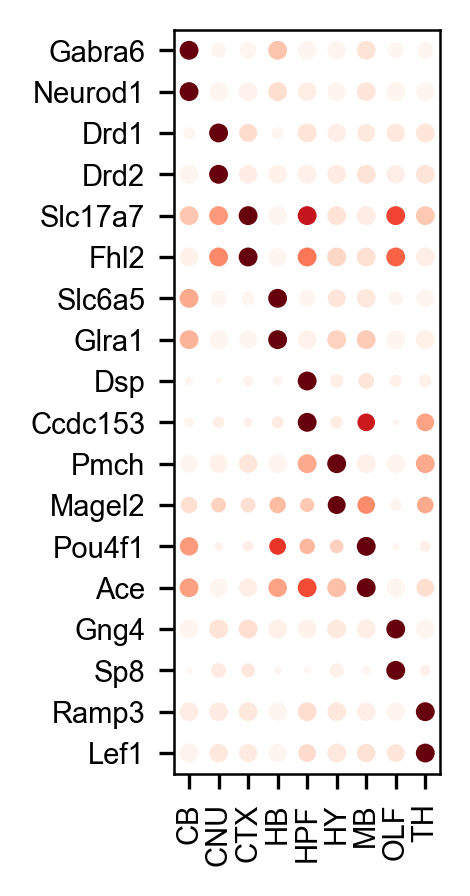

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize

# ---------------- 参数 ----------------
groupby = "cluster"   # adata.obs 分组列
genes = [
    "Gabra6","Neurod1","Drd1","Drd2","Slc17a7","Fhl2","Slc6a5","Glra1",
    "Dsp","Ccdc153","Pmch","Magel2","Pou4f1","Ace","Gng4","Sp8","Ramp3","Lef1",
]

EXP_THRESH = 0.0      # 表达阈值：>该值视为表达
MAX_DIAM_MM = 1.6     # 最大点直径（mm）
MIN_DIAM_MM = 0.25    # 最小点直径（mm）

# 固定成品尺寸（mm）
FIG_W_MM = 45
FIG_H_MM = 75

# 输出文件名
out_base = "dotplot_35x75mm"

# ---------------- 全局样式：Arial 7pt ----------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "none"
})

# ---------------- 输入检查 ----------------
if groupby not in adata.obs:
    raise ValueError(f"adata.obs 中找不到列：{groupby}")

clusters = list(pd.Categorical(adata.obs[groupby]).categories.astype(str))
G = len(clusters)

varset = set(map(str, adata.var_names))
genes_clean = [g for g in genes if g in varset]
miss = [g for g in genes if g not in varset]
if miss:
    print("未找到的基因（已忽略）：", miss)
if not genes_clean:
    raise ValueError("给定基因均不在 adata.var_names 中。")
M = len(genes_clean)

# 取表达矩阵（优先 raw）
if getattr(adata, "raw", None) is not None:
    X = adata.raw[:, genes_clean].X
else:
    X = adata[:, genes_clean].X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.asarray(X, dtype=float)  # n_cells x M

# ---------------- 计算 mean / frac ----------------
obs_groups = pd.Categorical(adata.obs[groupby], categories=clusters)
g_index = obs_groups.codes  # 0..G-1

mean_expr = np.zeros((G, M), dtype=float)
frac_expr = np.zeros((G, M), dtype=float)

for gi in range(G):
    sel = (g_index == gi)
    if not np.any(sel):
        continue
    Xg = X[sel, :]
    frac_expr[gi, :] = (Xg > EXP_THRESH).mean(axis=0)
    mean_expr[gi, :] = Xg.mean(axis=0)

# 颜色：每个基因在 cluster 间 0..1 归一化
mean_norm = mean_expr.copy()
for j in range(M):
    col = mean_expr[:, j]
    cmin, cmax = np.nanmin(col), np.nanmax(col)
    mean_norm[:, j] = (col - cmin) / (cmax - cmin) if (cmax > cmin) else 0.0

cmap = get_cmap("Reds")
colors = cmap(mean_norm)  # (G, M, 4)

# 点面积：mm -> points^2
def mm_to_pt(mm): 
    return mm * 72.0 / 25.4

max_area = (mm_to_pt(MAX_DIAM_MM))**2
min_area = (mm_to_pt(MIN_DIAM_MM))**2
areas = min_area + frac_expr * (max_area - min_area)  # (G, M)

# ---------------- 固定画布尺寸：35mm × 75mm ----------------
fig_w_in = FIG_W_MM / 25.4
fig_h_in = FIG_H_MM / 25.4
fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in), dpi=300, facecolor="none")

# 坐标：X=cluster，Y=gene（每行一个基因）
xx = np.tile(np.arange(G), M)         # length M*G
yy = np.repeat(np.arange(M), G)

cc = colors.transpose(1, 0, 2).reshape(-1, 4)  # (M*G, 4)
ss = areas.transpose(1, 0).ravel()             # (M*G,)

ax.scatter(xx, yy, s=ss, c=cc, marker="o", linewidths=0)

ax.set_xlim(-0.5, G - 0.5)
ax.set_ylim(-0.5, M - 0.5)
ax.set_xticks(np.arange(G))
ax.set_yticks(np.arange(M))
ax.set_xticklabels(clusters, rotation=90, ha="center")  # 宽度很窄，建议90度
ax.set_yticklabels(genes_clean)
ax.invert_yaxis()

# 边框线宽
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)

ax.set_xlabel("")
ax.set_ylabel("")

# 关键：在固定尺寸内手动留边（不要 bbox_inches='tight'）
# 35mm 宽很窄：left 给大一点以放下基因名；bottom 给一点放 cluster 名
fig.subplots_adjust(left=0.48, right=0.98, top=0.98, bottom=0.14)

# ---------------- 保存：保证导出尺寸不变 ----------------
# 不要 bbox_inches="tight"，否则尺寸会被改变
fig.savefig(out_base + ".pdf", transparent=True)
fig.savefig(out_base + ".svg", transparent=True)
fig.savefig(out_base + ".png", dpi=600, transparent=True)
plt.show()


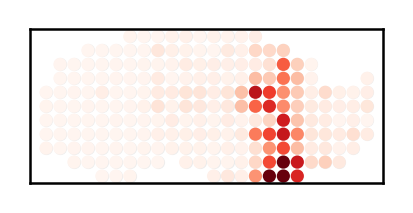

Saved: data\spatial_pipeline_out\spatial_expr_Drd1_ax3x1p3cm.png
Saved: data\spatial_pipeline_out\spatial_expr_Drd1_ax3x1p3cm.svg
Saved: data\spatial_pipeline_out\spatial_expr_Drd1_ax3x1p3cm.pdf


In [83]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pathlib import Path

# ===== 基本参数 =====
gene_name = "Drd1"
out_dir = Path("data/spatial_pipeline_out"); out_dir.mkdir(parents=True, exist_ok=True)
stem = out_dir / f"spatial_expr_{gene_name}_ax3x1p3cm"

invert_y  = True
s_pt2     = 10.0   # 点大小
alpha     = 1.0
bg_gray   = 0.85
norm_mode = "percentile"
q_low, q_high = 1, 99

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

# ===== 数据 =====
if gene_name not in adata.var_names and not (getattr(adata, "raw", None) is not None and gene_name in adata.raw.var_names):
    raise ValueError(f"{gene_name} 不在 adata 里")

x = np.asarray(adata.obs["x"], float)
y = np.asarray(adata.obs["y"], float)

if getattr(adata, "raw", None) is not None and gene_name in adata.raw.var_names:
    expr = adata.raw[:, [gene_name]].X
else:
    expr = adata[:, [gene_name]].X
if hasattr(expr, "toarray"):
    expr = expr.toarray()
expr = np.asarray(expr, float).ravel()

# ===== 标准化 =====
if norm_mode == "percentile":
    vmin = np.nanpercentile(expr, q_low)
    vmax = np.nanpercentile(expr, q_high)
else:
    vmin = np.nanmin(expr); vmax = np.nanmax(expr)

if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or np.isclose(vmin, vmax):
    expr_norm = np.zeros_like(expr)
else:
    expr_norm = (expr - vmin) / (vmax - vmin)
    expr_norm = np.clip(expr_norm, 0, 1)

norm01 = Normalize(0, 1, clip=True)

# ===== 精确尺寸部分 =====
cm2in = 1 / 2.54

# 主图：宽 3 cm，高 1.3 cm
ax_w_in = 3.0 * cm2in
ax_h_in = 1.3 * cm2in

# 边距
left_in   = 0.20
bottom_in = 0.25
top_in    = 0.10
right_in  = 0.00   # 没有 colorbar 就可以是 0

# figure 宽高 = 边距 + 主图
fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

fig = plt.figure(figsize=(fig_w, fig_h), dpi=300, facecolor="none")

# 主图轴
ax = fig.add_axes([
    left_in / fig_w,
    bottom_in / fig_h,
    ax_w_in / fig_w,
    ax_h_in / fig_h
])

# ===== 画 =====
if bg_gray is not None:
    ax.scatter(x, y, s=s_pt2, c=[(bg_gray, bg_gray, bg_gray)],
               alpha=0.5, linewidths=0)

sc = ax.scatter(
    x, y,
    s=s_pt2,
    c=expr_norm,
    cmap="Reds",
    norm=norm01,
    alpha=alpha,
    linewidths=0
)

ax.set_aspect("equal", adjustable="box")
if invert_y:
    ax.invert_yaxis()

for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.6)

ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(""); ax.set_ylabel("")

fig.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
fig.savefig(stem.with_suffix(".svg"),              bbox_inches="tight")
fig.savefig(stem.with_suffix(".pdf"),              bbox_inches="tight")
plt.show()

print("Saved:", stem.with_suffix(".png"))
print("Saved:", stem.with_suffix(".svg"))
print("Saved:", stem.with_suffix(".pdf"))


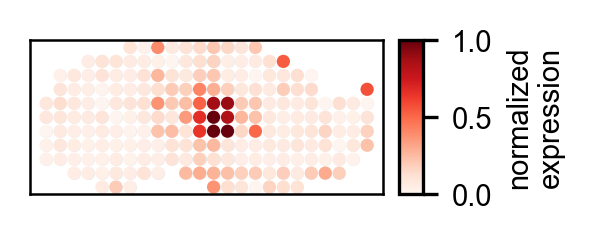

Saved: data\spatial_pipeline_out\spatial_expr_Lef1_ax3x1p3cm.png
Saved: data\spatial_pipeline_out\spatial_expr_Lef1_ax3x1p3cm.svg
Saved: data\spatial_pipeline_out\spatial_expr_Lef1_ax3x1p3cm.pdf


In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pathlib import Path

# ===== 基本参数 =====
gene_name = "Lef1"
out_dir = Path("data/spatial_pipeline_out"); out_dir.mkdir(parents=True, exist_ok=True)
stem = out_dir / f"spatial_expr_{gene_name}_ax3x1p3cm"

invert_y  = True
s_pt2     = 10.0   # 点稍微大点，不然1.3cm高里看着太小
alpha     = 1.0
bg_gray   = 0.85
norm_mode = "percentile"
q_low, q_high = 1, 99

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

# ===== 数据 =====
if gene_name not in adata.var_names and not (getattr(adata, "raw", None) is not None and gene_name in adata.raw.var_names):
    raise ValueError(f"{gene_name} 不在 adata 里")

x = np.asarray(adata.obs["x"], float)
y = np.asarray(adata.obs["y"], float)

if getattr(adata, "raw", None) is not None and gene_name in adata.raw.var_names:
    expr = adata.raw[:, [gene_name]].X
else:
    expr = adata[:, [gene_name]].X
if hasattr(expr, "toarray"):
    expr = expr.toarray()
expr = np.asarray(expr, float).ravel()

# ===== 标准化 =====
if norm_mode == "percentile":
    vmin = np.nanpercentile(expr, q_low)
    vmax = np.nanpercentile(expr, q_high)
else:
    vmin = np.nanmin(expr); vmax = np.nanmax(expr)

if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or np.isclose(vmin, vmax):
    expr_norm = np.zeros_like(expr)
else:
    expr_norm = (expr - vmin) / (vmax - vmin)
    expr_norm = np.clip(expr_norm, 0, 1)

norm01 = Normalize(0, 1, clip=True)

# ===== 精确尺寸部分 =====
cm2in = 1 / 2.54

# 主图：宽 3 cm，高 1.3 cm
ax_w_in = 3.0 * cm2in
ax_h_in = 1.3 * cm2in

# 边距 + 细色条
left_in   = 0.20
bottom_in = 0.25
top_in    = 0.10
gap_in    = 0.05
cb_w_in   = 0.08   # 很细的colorbar
right_in  = 0.00

fig_w = left_in + ax_w_in + gap_in + cb_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

fig = plt.figure(figsize=(fig_w, fig_h), dpi=300, facecolor="none")

# 主图轴：真的就是 3cm × 1.3cm
ax = fig.add_axes([
    left_in / fig_w,
    bottom_in / fig_h,
    ax_w_in / fig_w,
    ax_h_in / fig_h
])

# 右边的colorbar轴：跟主图同高，很细
cax = fig.add_axes([
    (left_in + ax_w_in + gap_in) / fig_w,
    bottom_in / fig_h,
    cb_w_in / fig_w,
    ax_h_in / fig_h
])

# ===== 画 =====
if bg_gray is not None:
    ax.scatter(x, y, s=s_pt2, c=[(bg_gray, bg_gray, bg_gray)], alpha=0.5, linewidths=0)

sc = ax.scatter(x, y, s=s_pt2, c=expr_norm, cmap="Reds", norm=norm01, alpha=alpha, linewidths=0)

ax.set_aspect("equal", adjustable="box")
if invert_y:
    ax.invert_yaxis()

for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.6)

ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(""); ax.set_ylabel("")

cb = plt.colorbar(sc, cax=cax)
cb.ax.tick_params(labelsize=7)
cb.set_ticks([0.0, 0.5, 1.0])
cb.set_label("normalized\nexpression", fontsize=7, rotation=90, labelpad=3)

# 不要 tight_layout
fig.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
fig.savefig(stem.with_suffix(".svg"),              bbox_inches="tight")
fig.savefig(stem.with_suffix(".pdf"),              bbox_inches="tight")
plt.show()

print("Saved:", stem.with_suffix(".png"))
print("Saved:", stem.with_suffix(".svg"))
print("Saved:", stem.with_suffix(".pdf"))
